# Multilingual MoE Routing Analysis (RQ3)

This notebook analyses whether MoE routing in the **multilingual models** reflects:

1. **Language specialisation** — do routers assign different experts to different languages?
2. **Age specialisation within each language** — after child fine-tuning, do routers distinguish adult vs. child speech?
3. **Cross-lingual consistency** — are the same experts child-preferred across EN, NL, and DE?

### Models analysed
| Internal key | Thesis label | Description |
|---|---|---|
| `adult_moe` | ML-MoE$_{CV}$ | Multilingual MoE pretrained on Common Voice adult speech only |
| `child_moe_lb_off` | ML-MoE$_{LB-off}$ | Fine-tuned on child speech, load balancing **disabled** |
| `child_moe_lb_on` | ML-MoE$_{LB-on}$ | Fine-tuned on child speech, load balancing **enabled** |

### Design notes
- All routing comparisons use a **4-hour cap per language/age group** to prevent larger datasets from dominating the analysis.
- Capping is done at the **utterance level** (all 17 layer rows for each utterance are kept together).
- Bootstrap CIs (500 resamples) are computed via utterance-level resampling with replacement.
- Polish/PAVSig results are reported separately with explicit caveats (clinical sigmatism corpus — not representative of typical child speech).

### Output directory
All figures are saved as PNG to `routing_outputs_multilingual_analysis/`.

---
## Cell 0 — Imports, paths, and constants

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
ROUTING_DIR   = Path("/lp-dev/amelia/inclusive-asr-moe/analysis/routing/routing_outputs_multilingual")
OUTPUT_DIR    = Path("/lp-dev/amelia/inclusive-asr-moe/analysis/routing/routing_outputs_multilingual_analysis")
EN_ONLY_DIR   = Path("/lp-dev/amelia/inclusive-asr-moe/analysis/routing/routing_outputs_en")

OUTPUT_DIR.mkdir(exist_ok=True)

EN_ONLY_CSV = EN_ONLY_DIR / "child_moe_lb_off_routing.csv"

# ---------------------------------------------------------------------------
# Model identifiers
# ---------------------------------------------------------------------------
# Internal keys match CSV filenames and must not change.
MODEL_NAMES   = ["adult_moe", "child_moe_lb_off", "child_moe_lb_on"]
PRIMARY_MODEL = "child_moe_lb_off"   # Main model for thesis figures

# Display labels used only in plots, legends, and printed summaries.
MODEL_DISPLAY_NAMES = {
    "adult_moe":        r"ML-MoE$_{CV}$",
    "child_moe_lb_off": r"ML-MoE$_{LB-off}$",
    "child_moe_lb_on":  r"ML-MoE$_{LB-on}$",
}
DENSE_MODEL_DISPLAY_NAMES = {
    "ml_dense_cv":    r"ML-Dense$_{CV}$",
    "ml_dense_child": r"ML-Dense$_{child}$",
}

def model_label(model_key: str) -> str:
    """Return the thesis display label for a model's internal key."""
    return MODEL_DISPLAY_NAMES.get(
        model_key,
        DENSE_MODEL_DISPLAY_NAMES.get(model_key, model_key),
    )

# ---------------------------------------------------------------------------
# Architecture constants
# ---------------------------------------------------------------------------
NUM_LAYERS   = 17    # FastConformer encoder layers
NUM_EXPERTS  = 8     # Experts per MoE layer (multilingual models)
TOP_K        = 2     # Experts selected per token
UNIFORM_LOAD = TOP_K / NUM_EXPERTS   # Expected load per expert under uniform routing

EXPERT_PROB_COLS = [f"expert_{i}_prob" for i in range(NUM_EXPERTS)]

# ---------------------------------------------------------------------------
# Language groupings
# ---------------------------------------------------------------------------
ALL_LANGUAGES = ["en", "nl", "de", "pl"]
AGE_LANGUAGES = ["en", "nl", "de"]  # PL/PAVSig reported separately with caveats

# ---------------------------------------------------------------------------
# Bootstrap and capping parameters
# ---------------------------------------------------------------------------
N_BOOT           = 500
TARGET_HOURS     = 4
TARGET_SECONDS   = TARGET_HOURS * 3600

RNG = np.random.default_rng(42)

# ---------------------------------------------------------------------------
# Plot colours
# ---------------------------------------------------------------------------
MODEL_COLORS = {
    "adult_moe":        "C4",
    "child_moe_lb_off": "C0",
    "child_moe_lb_on":  "C2",
}
LANG_COLORS = {"en": "C0", "nl": "C1", "de": "C2", "pl": "C3"}

# ---------------------------------------------------------------------------
# JSD helper
# ---------------------------------------------------------------------------
def jsd(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon Divergence (bits). scipy.jensenshannon returns sqrt(JSD), so we square it."""
    return jensenshannon(p, q, base=2.0) ** 2

# ---------------------------------------------------------------------------
print("ROUTING_DIR :", ROUTING_DIR)
print("OUTPUT_DIR  :", OUTPUT_DIR)
print(f"Duration cap : {TARGET_HOURS} h per language/age group")

ROUTING_DIR : /lp-dev/amelia/inclusive-asr-moe/analysis/routing/routing_outputs_multilingual
OUTPUT_DIR  : /lp-dev/amelia/inclusive-asr-moe/analysis/routing/routing_outputs_multilingual_analysis
Duration cap : 4 h per language/age group


---
## Cell 1 — Load routing CSVs

Each CSV contains one row per **(utterance, layer)** with columns:
- `utterance_id`, `age_group`, `language`, `dataset_source`, `layer_idx`
- `top1_expert`, `top2_expert` — indices of the two selected experts
- `expert_0_prob … expert_7_prob` — soft routing probabilities over all experts
- `duration_sec`, `model`

A warning is printed for any missing files or columns; the notebook continues gracefully.

In [2]:
def get_expert_prob_cols(df: pd.DataFrame) -> list[str]:
    """Return expert probability columns sorted by expert index."""
    cols = [c for c in df.columns if c.startswith("expert_") and c.endswith("_prob")]
    return sorted(cols, key=lambda x: int(x.split("_")[1]))


def load_routing_csv(
    path: Path,
    name: str,
    expected_experts: int | None = None,
) -> pd.DataFrame | None:
    """Load a routing CSV with validation. Returns None if the file is missing."""
    if not path.exists():
        print(f"WARNING: missing {name} at {path}")
        return None

    df = pd.read_csv(path)
    prob_cols = get_expert_prob_cols(df)

    required_cols = [
        "utterance_id", "age_group", "language", "dataset_source",
        "layer_idx", "top1_expert", "duration_sec", "model",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"WARNING: {name} missing columns: {missing}")
    if "top2_expert" not in df.columns:
        print(f"WARNING: {name} missing top2_expert; continuing anyway")
    if expected_experts is not None and len(prob_cols) != expected_experts:
        print(f"WARNING: {name} has {len(prob_cols)} expert prob cols, expected {expected_experts}")

    print(f"  {name}: {df.shape[0]:,} rows, {df.shape[1]} cols, experts={len(prob_cols)}")
    return df


# --- Load multilingual models ---
print("Loading multilingual routing CSVs...")
routing_dfs = {}
for model_name in MODEL_NAMES:
    path = ROUTING_DIR / f"{model_name}_routing.csv"
    routing_dfs[model_name] = load_routing_csv(path, model_name, expected_experts=NUM_EXPERTS)

# --- Load English-only model (4 experts) for optional comparison ---
print("\nLoading English-only model CSV...")
en_only_df = load_routing_csv(EN_ONLY_CSV, "english_child_moe_lb_off", expected_experts=4)

# --- Sanity check: utterance counts and hours per language/age group ---
print("\n--- Sanity check: multilingual files ---")
for model_name, df in routing_dfs.items():
    if df is None or df.empty:
        print(f"{model_name}: missing/empty")
        continue

    layer0 = df[df["layer_idx"] == 0].copy()
    print(f"\n{model_name}")
    print("Utterances per language/age:")
    print(
        layer0.groupby(["language", "age_group"])["utterance_id"]
        .nunique()
        .reset_index(name="n_utterances")
        .to_string(index=False)
    )
    print("Duration per language/age, hours:")
    print(
        layer0.groupby(["language", "age_group"])["duration_sec"]
        .sum().div(3600)
        .reset_index(name="hours")
        .to_string(index=False)
    )

Loading multilingual routing CSVs...
  adult_moe: 180,217 rows, 18 cols, experts=8
  child_moe_lb_off: 180,217 rows, 18 cols, experts=8
  child_moe_lb_on: 180,217 rows, 18 cols, experts=8

Loading English-only model CSV...
  english_child_moe_lb_off: 268,413 rows, 14 cols, experts=4

--- Sanity check: multilingual files ---

adult_moe
Utterances per language/age:
language age_group  n_utterances
      de     adult          1500
      de     child          1500
      en     adult          1500
      en     child          1500
      nl     adult          1500
      nl     child          1095
      pl     adult          1500
      pl     child           506
Duration per language/age, hours:
language age_group    hours
      de     adult 2.460166
      de     child 1.287966
      en     adult 3.176800
      en     child 3.776894
      nl     adult 1.948058
      nl     child 0.539313
      pl     adult 2.035387
      pl     child 0.134852

child_moe_lb_off
Utterances per language/age:
lang

---
## Cell 2 — Build 4-hour capped analysis sets

To keep routing comparisons fair across languages and age groups (which differ substantially in size), each **(language, age group)** subset is capped at **4 hours** of speech by sampling whole utterances without replacement.

**Why whole utterances?** Each utterance appears once per layer (17 rows total). Sampling at the row level would break the per-utterance grouping and artificially inflate utterance counts. All 17 layer rows for each selected utterance are kept together.

The capped DataFrames in `routing_dfs_4h` are used for all subsequent analyses.

In [3]:
def sample_utterances_to_duration(
    df: pd.DataFrame,
    target_seconds: float,
    rng: np.random.Generator,
    group_name: str = "",
) -> pd.DataFrame:
    """
    Greedily sample whole utterances (without replacement) until
    the cumulative duration reaches `target_seconds`. All layer
    rows for each selected utterance are retained.
    """
    if df is None or df.empty:
        return df.iloc[0:0]

    utt = (
        df[df["layer_idx"] == 0][["utterance_id", "duration_sec"]]
        .drop_duplicates("utterance_id")
        .copy()
    )
    utt["duration_sec"] = utt["duration_sec"].astype(float)
    utt = utt.dropna(subset=["duration_sec"])
    if utt.empty:
        return df.iloc[0:0]

    utt = utt.sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000_000)))

    picked, total = [], 0.0
    for _, row in utt.iterrows():
        picked.append(row["utterance_id"])
        total += float(row["duration_sec"])
        if total >= target_seconds:
            break

    print(f"{group_name}: selected {len(picked):,}/{len(utt):,} utterances, {total / 3600:.2f} h")
    return df[df["utterance_id"].isin(picked)].copy()


def make_4h_capped_df(
    df: pd.DataFrame,
    group_cols: list[str],
    target_seconds: float,
    rng: np.random.Generator,
) -> pd.DataFrame:
    """Apply `sample_utterances_to_duration` independently per group and concatenate."""
    parts = []
    for group_key, group_df in df.groupby(group_cols):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        group_name = "/".join(str(x) for x in group_key)
        part = sample_utterances_to_duration(group_df, target_seconds, rng, group_name)
        if not part.empty:
            parts.append(part)
    if not parts:
        return df.iloc[0:0].copy()
    return pd.concat(parts, ignore_index=True)


# Cap each (language, age_group) subset at 4 hours per model.
routing_dfs_4h = {}
print("Building 4-hour capped sets per (language, age_group)...")
for model_name, df in routing_dfs.items():
    if df is None or df.empty:
        routing_dfs_4h[model_name] = df
        continue
    print(f"\n{'=' * 80}\n{model_name}\n{'=' * 80}")
    routing_dfs_4h[model_name] = make_4h_capped_df(
        df, group_cols=["language", "age_group"],
        target_seconds=TARGET_SECONDS, rng=RNG,
    )

# Summary
print("\n--- 4-hour capped set summary ---")
for model_name, df in routing_dfs_4h.items():
    if df is None or df.empty:
        continue
    layer0 = df[df["layer_idx"] == 0]
    print(f"\n{model_name}")
    print(
        layer0.groupby(["language", "age_group"])
        .agg(
            n_utterances=("utterance_id", "nunique"),
            hours=("duration_sec", lambda x: x.sum() / 3600),
        )
        .reset_index()
        .to_string(index=False)
    )

Building 4-hour capped sets per (language, age_group)...

adult_moe
de/adult: selected 1,500/1,500 utterances, 2.46 h
de/child: selected 1,500/1,500 utterances, 1.29 h
en/adult: selected 1,500/1,500 utterances, 3.18 h
en/child: selected 1,500/1,500 utterances, 3.78 h
nl/adult: selected 1,500/1,500 utterances, 1.95 h
nl/child: selected 1,095/1,095 utterances, 0.54 h
pl/adult: selected 1,500/1,500 utterances, 2.04 h
pl/child: selected 506/506 utterances, 0.13 h

child_moe_lb_off
de/adult: selected 1,500/1,500 utterances, 2.46 h
de/child: selected 1,500/1,500 utterances, 1.29 h
en/adult: selected 1,500/1,500 utterances, 3.18 h
en/child: selected 1,500/1,500 utterances, 3.78 h
nl/adult: selected 1,500/1,500 utterances, 1.95 h
nl/child: selected 1,095/1,095 utterances, 0.54 h
pl/adult: selected 1,500/1,500 utterances, 2.04 h
pl/child: selected 506/506 utterances, 0.13 h

child_moe_lb_on
de/adult: selected 1,500/1,500 utterances, 2.46 h
de/child: selected 1,500/1,500 utterances, 1.29 h
en/ad

---
## Cell 3 — Distribution helpers

Two helper functions used throughout the analysis:

- **`weighted_distribution`** — computes a duration-weighted expert probability distribution from a group of utterances at a single layer. Weighting by duration ensures that longer utterances contribute proportionally to the aggregate distribution.
- **`build_distributions_by_lang_age`** — applies the above across all models, layers, languages, and age groups, returning a nested dict `distributions[model][layer][(language, age_group)]`.

In [4]:
def weighted_distribution(
    group_df: pd.DataFrame,
    prob_cols: list[str] = EXPERT_PROB_COLS,
) -> np.ndarray | None:
    """
    Duration-weighted routing distribution over experts.
    Each row contributes its expert probability vector scaled by utterance duration,
    so longer utterances have proportionally greater influence on the aggregate.
    Returns a normalised probability vector of length len(prob_cols).
    """
    if group_df is None or group_df.empty:
        return None
    probs   = group_df[prob_cols].values.astype(float)
    weights = group_df["duration_sec"].values.astype(float) if "duration_sec" in group_df.columns else np.ones(len(group_df))
    totals  = (probs * weights[:, None]).sum(axis=0)
    denom   = totals.sum()
    return totals / denom if denom > 0 else np.zeros(len(prob_cols))


def layer_distributions(
    df: pd.DataFrame,
    prob_cols: list[str] = EXPERT_PROB_COLS,
) -> dict[int, np.ndarray]:
    """Compute duration-weighted expert distributions per layer for a single group."""
    return {
        int(layer_idx): weighted_distribution(layer_df, prob_cols=prob_cols)
        for layer_idx, layer_df in df.groupby("layer_idx")
    }


def build_distributions_by_lang_age(
    dfs: dict[str, pd.DataFrame],
    prob_cols: list[str] = EXPERT_PROB_COLS,
) -> dict:
    """
    Build nested expert distributions for all models, layers, languages, and age groups.
    Structure: distributions[model][layer][(language, age_group)] = np.ndarray
    """
    distributions = {}
    for model_name, df in dfs.items():
        if df is None or df.empty:
            distributions[model_name] = {}
            continue
        model_dist = {}
        for layer_idx, layer_df in df.groupby("layer_idx"):
            model_dist[int(layer_idx)] = {
                (lang, age): weighted_distribution(g, prob_cols=prob_cols)
                for (lang, age), g in layer_df.groupby(["language", "age_group"])
            }
        distributions[model_name] = model_dist
    return distributions


# Compute distributions on the 4h-capped data used for all subsequent analyses.
distributions = build_distributions_by_lang_age(routing_dfs_4h)

# Quick sanity check
print("Distribution check (sums should equal 1.0):")
for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})
    if not md:
        print(f"  {model_name}: no distributions")
        continue
    layer0 = sorted(md.keys())[0]
    key0   = sorted(md[layer0].keys())[0]
    vec    = md[layer0][key0]
    print(f"  {model_name}, layer {layer0}, {key0}: sum={vec.sum():.6f}, first 4={np.round(vec[:4], 4)}")

Distribution check (sums should equal 1.0):
  adult_moe, layer 0, ('de', 'adult'): sum=1.000000, first 4=[0.1482 0.208  0.0937 0.1004]
  child_moe_lb_off, layer 0, ('de', 'adult'): sum=1.000000, first 4=[0.163  0.2696 0.0636 0.0405]
  child_moe_lb_on, layer 0, ('de', 'adult'): sum=1.000000, first 4=[0.1794 0.2521 0.069  0.0635]


---
## Cell 4 — Language specialisation: pairwise JSD on adult speech

To test whether the router distinguishes languages at all, we compute the Jensen-Shannon Divergence between expert distributions for every pair of languages, using **adult speech only** (no age confound). A high JSD between, say, EN and DE means the router routes tokens from those languages differently.

This is done separately for each model to show how language specialisation evolves through pretraining and fine-tuning. One panel per model, one curve per language pair.

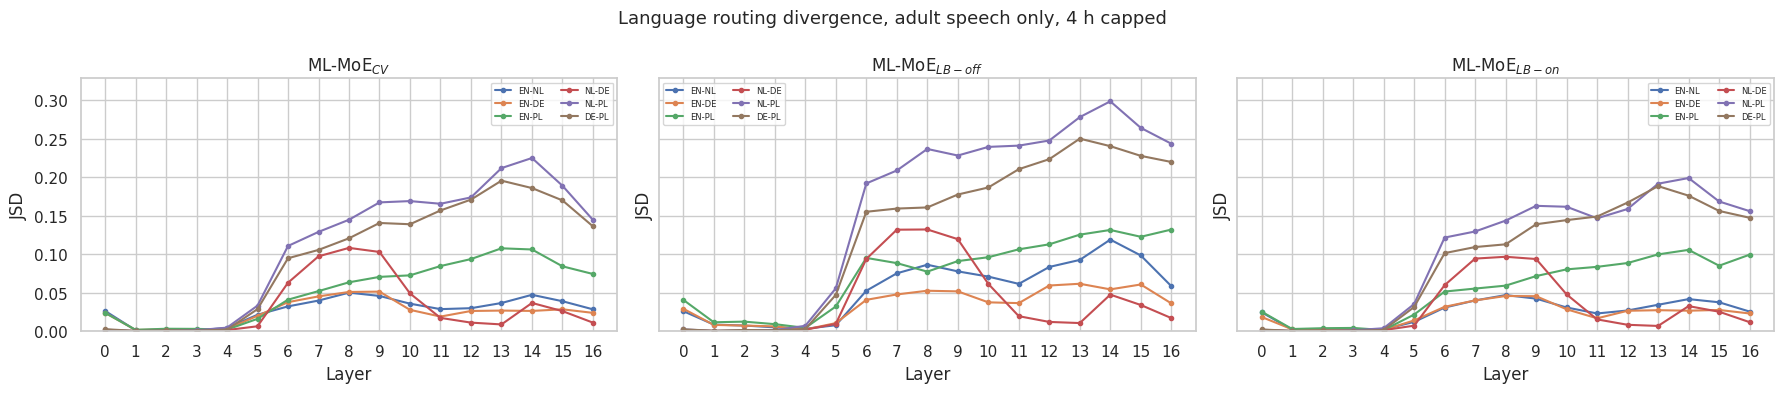


Mean adult-language JSD per pair — ML-MoE$_{LB-off}$:
  EN-NL: mean=0.054924, peak=0.118866
  EN-DE: mean=0.035452, peak=0.061604
  EN-PL: mean=0.075788, peak=0.131875
  NL-DE: mean=0.040819, peak=0.132021
  NL-PL: mean=0.161375, peak=0.298226
  DE-PL: mean=0.133226, peak=0.249822


In [5]:
lang_pairs       = list(combinations(ALL_LANGUAGES, 2))
lang_pair_labels = [f"{a.upper()}-{b.upper()}" for a, b in lang_pairs]

# Compute pairwise JSD per layer, per model
lang_jsd_by_model = {}
for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})
    lang_jsd_by_model[model_name] = {}
    for (lang_a, lang_b), label in zip(lang_pairs, lang_pair_labels):
        vals = []
        for layer in range(NUM_LAYERS):
            ld = md.get(layer, {})
            a  = ld.get((lang_a, "adult"))
            b  = ld.get((lang_b, "adult"))
            vals.append(jsd(a, b) if a is not None and b is not None else np.nan)
        lang_jsd_by_model[model_name][label] = vals

# Shared y-axis limit across all panels
all_vals = [
    v for model_dict in lang_jsd_by_model.values()
    for vals in model_dict.values() for v in vals if not np.isnan(v)
]
lang_ymax = max(all_vals) * 1.1 if all_vals else 0.01

# Plot
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(18, 4), sharey=True)
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODEL_NAMES):
    for label, vals in lang_jsd_by_model[model_name].items():
        ax.plot(range(NUM_LAYERS), vals, marker="o", markersize=3, label=label)
    ax.set_title(model_label(model_name))
    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD")
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_ylim(0, lang_ymax)
    ax.legend(fontsize=6, ncol=2)

plt.suptitle("Language routing divergence, adult speech only, 4 h capped", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "language_pairwise_jsd_all_models_4h.png", dpi=300)
plt.show()

# Print mean and peak JSD for the primary model
print(f"\nMean adult-language JSD per pair — {model_label(PRIMARY_MODEL)}:")
for label, vals in lang_jsd_by_model[PRIMARY_MODEL].items():
    valid = np.array([v for v in vals if not np.isnan(v)])
    if valid.size == 0:
        print(f"  {label}: mean=nan, peak=nan")
    else:
        print(f"  {label}: mean={valid.mean():.6f}, peak={valid.max():.6f}")

---
## Cell 5 — Language specialisation: per-language expert load heatmaps

For each model and language, we visualise **expert load deviation from uniform** across all 17 layers.

- **Uniform load** = TOP_K / NUM_EXPERTS = 2/8 = 0.25 (each expert receives exactly 25% of token mass under perfectly balanced routing).
- **Deviation** = observed load − uniform load.
- Red cells indicate over-used experts; blue cells indicate under-used experts for that language.

Structured patterns across layers indicate genuine language-driven expert specialisation rather than random routing.

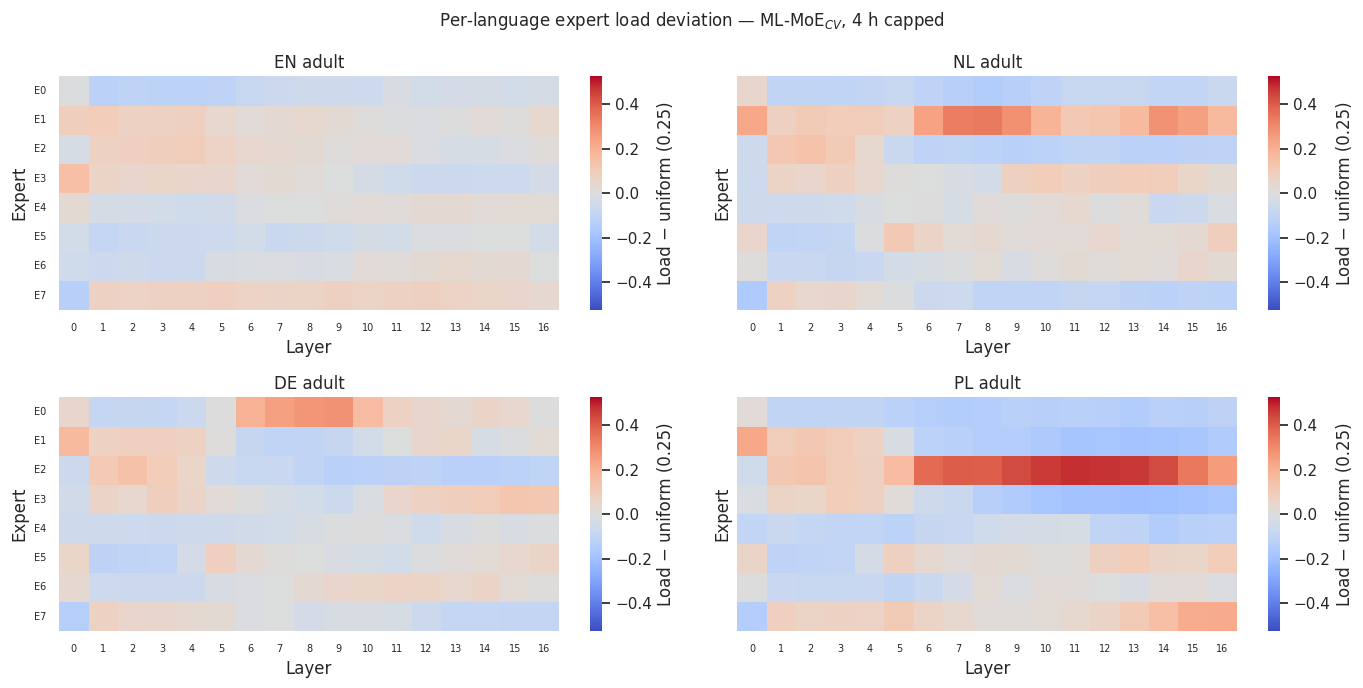

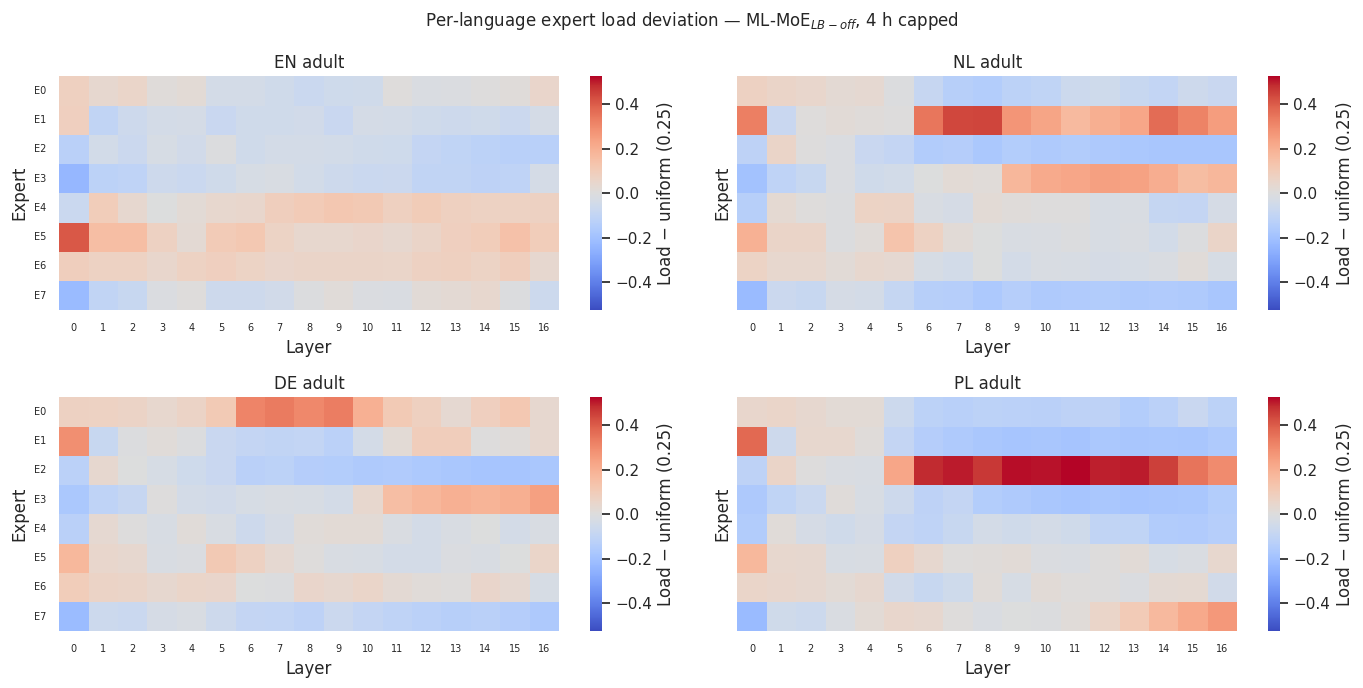

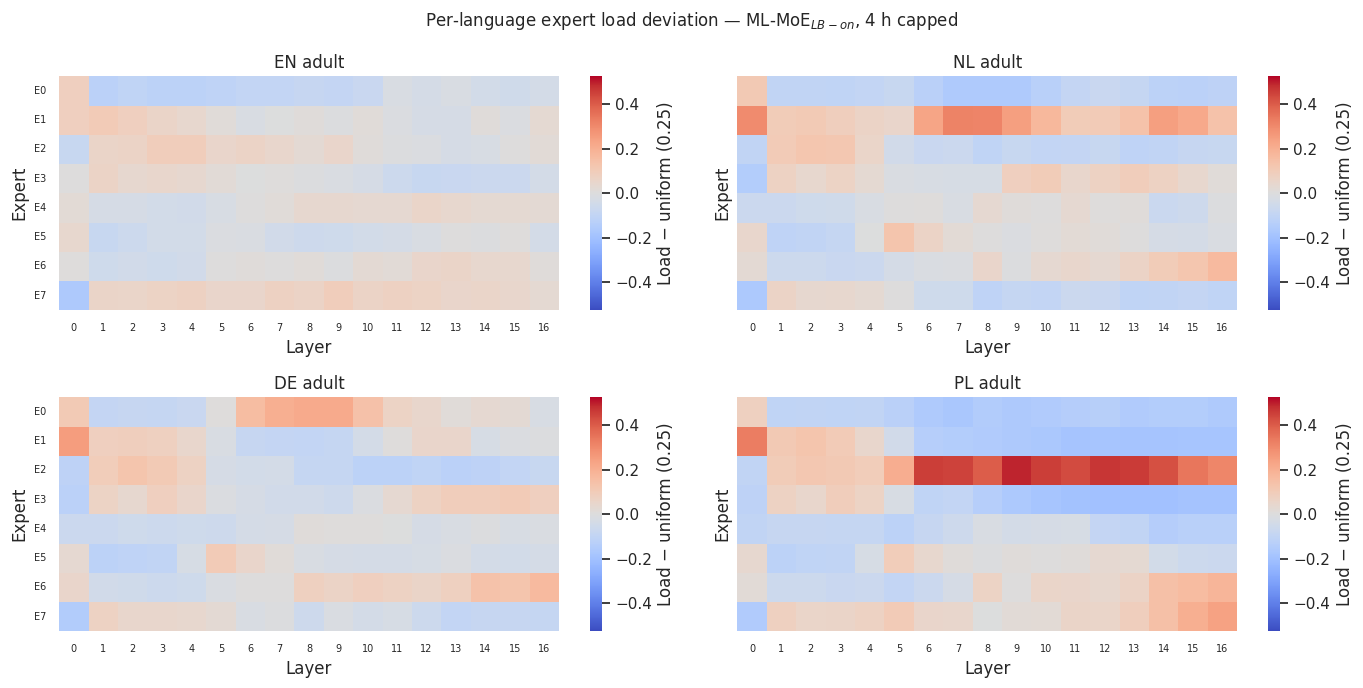

In [6]:
# Compute load deviation matrices: (NUM_EXPERTS × NUM_LAYERS) per model and language
language_load_deviation = {}
for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})
    language_load_deviation[model_name] = {}
    for lang in ALL_LANGUAGES:
        mat = np.full((NUM_EXPERTS, NUM_LAYERS), np.nan)
        for layer in range(NUM_LAYERS):
            dist = md.get(layer, {}).get((lang, "adult"))
            if dist is not None:
                mat[:, layer] = (dist * TOP_K) - UNIFORM_LOAD
        language_load_deviation[model_name][lang] = mat

# Shared colour scale across all models and languages
all_devs = np.array([
    x for model_dict in language_load_deviation.values()
    for mat in model_dict.values() for x in mat.ravel() if not np.isnan(x)
])
max_dev = np.max(np.abs(all_devs)) if all_devs.size else 1e-6
if max_dev == 0:
    max_dev = 1e-6

# One figure per model (2×2 grid of languages)
for model_name in MODEL_NAMES:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)
    for ax, lang in zip(axes.ravel(), ALL_LANGUAGES):
        mat = language_load_deviation[model_name][lang]
        sns.heatmap(
            mat, cmap="coolwarm", center=0, vmin=-max_dev, vmax=max_dev, ax=ax,
            cbar_kws={"label": f"Load − uniform ({UNIFORM_LOAD:.2f})"},
        )
        ax.set_title(f"{lang.upper()} adult")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Expert")
        ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
        ax.set_xticklabels(range(NUM_LAYERS), fontsize=7)
        ax.set_yticks(np.arange(NUM_EXPERTS) + 0.5)
        ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=7)

    plt.suptitle(f"Per-language expert load deviation — {model_label(model_name)}, 4 h capped", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"language_expert_load_{model_name}_4h.png", dpi=200)
    plt.show()

---
## Cell 6 — Age specialisation: observed within-language JSD

We now measure **within-language** routing divergence between adult and child speech. For each (model, language, layer) triple, JSD is computed between the adult and child expert distributions.

A high JSD means the router routes adult and child tokens differently within the same language — evidence of implicit age specialisation without demographic supervision.

The plot grid has:
- **Rows** = models (adult_moe, child_moe_lb_off, child_moe_lb_on)
- **Columns** = languages (EN, NL, DE)

Polish is excluded from this grid; it is covered separately in the PAVSig section.

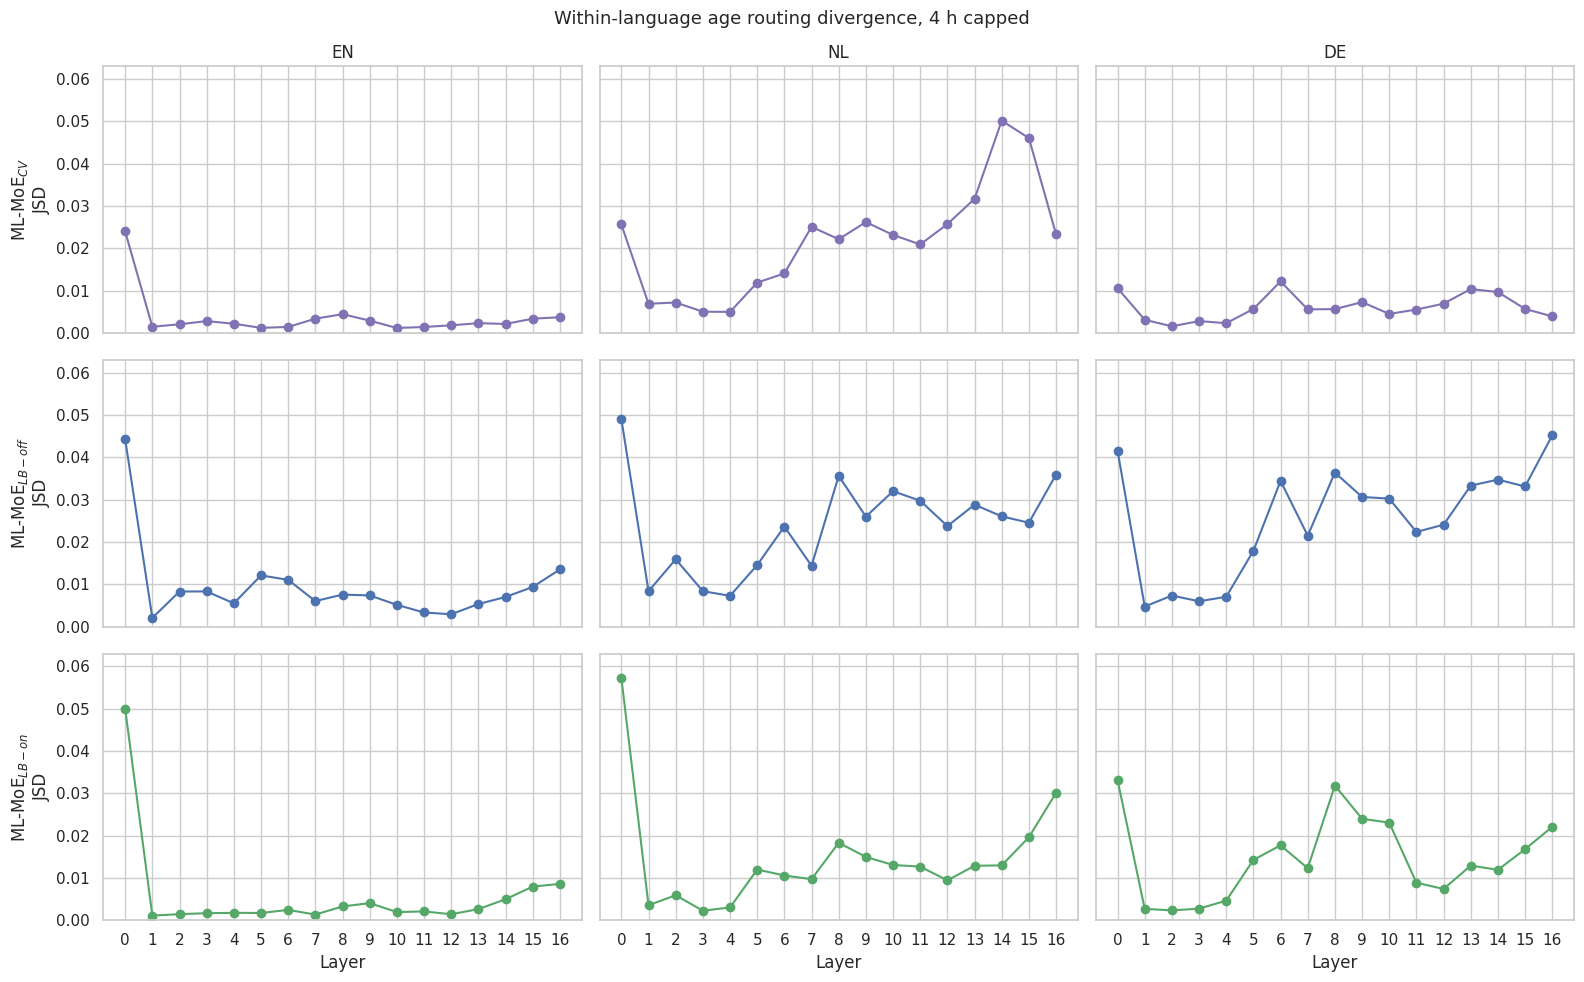


Peak age JSD, 4 h capped:
  ML-MoE$_{CV}$/EN: peak=0.023976 at layer 0
  ML-MoE$_{CV}$/NL: peak=0.050171 at layer 14
  ML-MoE$_{CV}$/DE: peak=0.012185 at layer 6
  ML-MoE$_{LB-off}$/EN: peak=0.044262 at layer 0
  ML-MoE$_{LB-off}$/NL: peak=0.049047 at layer 0
  ML-MoE$_{LB-off}$/DE: peak=0.045183 at layer 16
  ML-MoE$_{LB-on}$/EN: peak=0.049980 at layer 0
  ML-MoE$_{LB-on}$/NL: peak=0.057268 at layer 0
  ML-MoE$_{LB-on}$/DE: peak=0.033142 at layer 0


In [7]:
# Compute observed within-language age JSD per model, language, and layer
age_jsd_observed = {}
for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})
    for lang in AGE_LANGUAGES:
        vals = []
        for layer in range(NUM_LAYERS):
            ld    = md.get(layer, {})
            adult = ld.get((lang, "adult"))
            child = ld.get((lang, "child"))
            vals.append(jsd(adult, child) if adult is not None and child is not None else np.nan)
        age_jsd_observed[(model_name, lang)] = vals

# Shared y-axis limit
all_age_vals = [v for vals in age_jsd_observed.values() for v in vals if not np.isnan(v)]
age_ymax = max(all_age_vals) * 1.1 if all_age_vals else 0.01

# Plot grid: rows = models, columns = languages
fig, axes = plt.subplots(len(MODEL_NAMES), len(AGE_LANGUAGES), figsize=(16, 10), sharex=True, sharey=True)
if len(MODEL_NAMES)   == 1: axes = np.array([axes])
if len(AGE_LANGUAGES) == 1: axes = axes[:, None]

for r, model_name in enumerate(MODEL_NAMES):
    for c, lang in enumerate(AGE_LANGUAGES):
        ax   = axes[r, c]
        vals = age_jsd_observed[(model_name, lang)]
        ax.plot(range(NUM_LAYERS), vals, marker="o", color=MODEL_COLORS[model_name])
        ax.set_ylim(0, age_ymax)
        ax.set_xticks(range(NUM_LAYERS))
        if r == 0:                    ax.set_title(lang.upper())
        if c == 0:                    ax.set_ylabel(f"{model_label(model_name)}\nJSD")
        if r == len(MODEL_NAMES) - 1: ax.set_xlabel("Layer")

plt.suptitle("Within-language age routing divergence, 4 h capped", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_jsd_grid_models_languages_4h.png", dpi=200)
plt.show()

# Print peak layers
print("\nPeak age JSD, 4 h capped:")
for model_name in MODEL_NAMES:
    for lang in AGE_LANGUAGES:
        vals  = age_jsd_observed[(model_name, lang)]
        valid = [(i, v) for i, v in enumerate(vals) if not np.isnan(v)]
        if valid:
            peak_layer, peak_val = max(valid, key=lambda x: x[1])
            print(f"  {model_label(model_name)}/{lang.upper()}: peak={peak_val:.6f} at layer {peak_layer}")

---
## Cell 7 — Bootstrap confidence intervals for age JSD

To assess whether the observed age JSD values are statistically robust, we compute **95% bootstrap CIs** (500 resamples) using utterance-level resampling with replacement.

**Why utterance-level, not row-level?** Each utterance generates 17 rows (one per layer). Resampling rows independently would violate the dependence structure and artificially narrow the CIs.

**Performance note:** Expert probability arrays are precomputed as NumPy matrices outside the bootstrap loop. This avoids repeated DataFrame filtering inside the loop, reducing runtime from ~14 minutes to a few seconds.

Results are stored in `age_jsd_ci[(model_name, lang)]` as a DataFrame with columns `layer`, `ci_low`, `ci_high`.

In [8]:
def bootstrap_jsd_fast(
    adult_df: pd.DataFrame,
    child_df: pd.DataFrame,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Fast utterance-level bootstrap for age JSD.

    Precomputes (n_utterances × n_experts) duration-weighted probability matrices
    per layer, then resamples utterance indices with replacement inside the loop.
    This avoids DataFrame operations in the hot path.

    Returns
    -------
    np.ndarray of shape (n_boot, NUM_LAYERS) containing JSD values.
    """
    def precompute(df):
        """Returns {layer: (n_utterances × n_experts) array of duration-weighted probs}."""
        utt_ids   = df[df["layer_idx"] == 0]["utterance_id"].unique()
        utt_to_i  = {uid: i for i, uid in enumerate(utt_ids)}
        n_utt     = len(utt_ids)
        per_layer = {}
        for layer_idx, layer_df in df.groupby("layer_idx"):
            mat = np.zeros((n_utt, NUM_EXPERTS))
            for _, row in layer_df.iterrows():
                uid = row["utterance_id"]
                if uid not in utt_to_i:
                    continue
                dur  = float(row["duration_sec"]) if "duration_sec" in row.index else 1.0
                probs = row[EXPERT_PROB_COLS].values.astype(float)
                mat[utt_to_i[uid]] = probs * dur
            per_layer[int(layer_idx)] = mat
        return per_layer, n_utt

    adult_layers, n_adult = precompute(adult_df)
    child_layers, n_child = precompute(child_df)

    boot_jsd = np.full((n_boot, NUM_LAYERS), np.nan)
    for b in range(n_boot):
        a_idx = rng.integers(0, n_adult, size=n_adult)
        c_idx = rng.integers(0, n_child, size=n_child)
        for layer in range(NUM_LAYERS):
            a_mat = adult_layers.get(layer)
            c_mat = child_layers.get(layer)
            if a_mat is None or c_mat is None:
                continue
            a_sum = a_mat[a_idx].sum(axis=0)
            c_sum = c_mat[c_idx].sum(axis=0)
            a_d, c_d = a_sum.sum(), c_sum.sum()
            if a_d == 0 or c_d == 0:
                continue
            boot_jsd[b, layer] = jsd(a_sum / a_d, c_sum / c_d)
    return boot_jsd


age_jsd_ci = {}
for model_name in MODEL_NAMES:
    df = routing_dfs_4h.get(model_name)
    if df is None or df.empty:
        continue
    for lang in AGE_LANGUAGES:
        adult_df = df[(df["language"] == lang) & (df["age_group"] == "adult")]
        child_df = df[(df["language"] == lang) & (df["age_group"] == "child")]
        if adult_df.empty or child_df.empty:
            print(f"  Skipping {model_name}/{lang.upper()}: missing data")
            continue
        print(f"  Bootstrapping {model_name}/{lang.upper()}...", end=" ", flush=True)
        boot_jsd = bootstrap_jsd_fast(adult_df, child_df, N_BOOT, RNG)
        ci_rows = []
        for layer in range(NUM_LAYERS):
            vals = boot_jsd[:, layer]
            vals = vals[~np.isnan(vals)]
            if vals.size == 0:
                ci_rows.append({"layer": layer, "ci_low": np.nan, "ci_high": np.nan})
            else:
                ci_rows.append({
                    "layer":   layer,
                    "ci_low":  float(np.percentile(vals, 2.5)),
                    "ci_high": float(np.percentile(vals, 97.5)),
                })
        age_jsd_ci[(model_name, lang)] = pd.DataFrame(ci_rows)
        print("done")

  Bootstrapping adult_moe/EN... done
  Bootstrapping adult_moe/NL... done
  Bootstrapping adult_moe/DE... done
  Bootstrapping child_moe_lb_off/EN... done
  Bootstrapping child_moe_lb_off/NL... done
  Bootstrapping child_moe_lb_off/DE... done
  Bootstrapping child_moe_lb_on/EN... done
  Bootstrapping child_moe_lb_on/NL... done
  Bootstrapping child_moe_lb_on/DE... done


---
## Cell 8 — Age JSD with bootstrap confidence intervals (grid plot)

The same grid as Cell 6, now with shaded 95% bootstrap CIs. Layers where the CI does not overlap zero provide statistical support for age-correlated routing at that depth.

This is the primary evidence figure for RQ2/RQ3 (multilingual age specialisation).

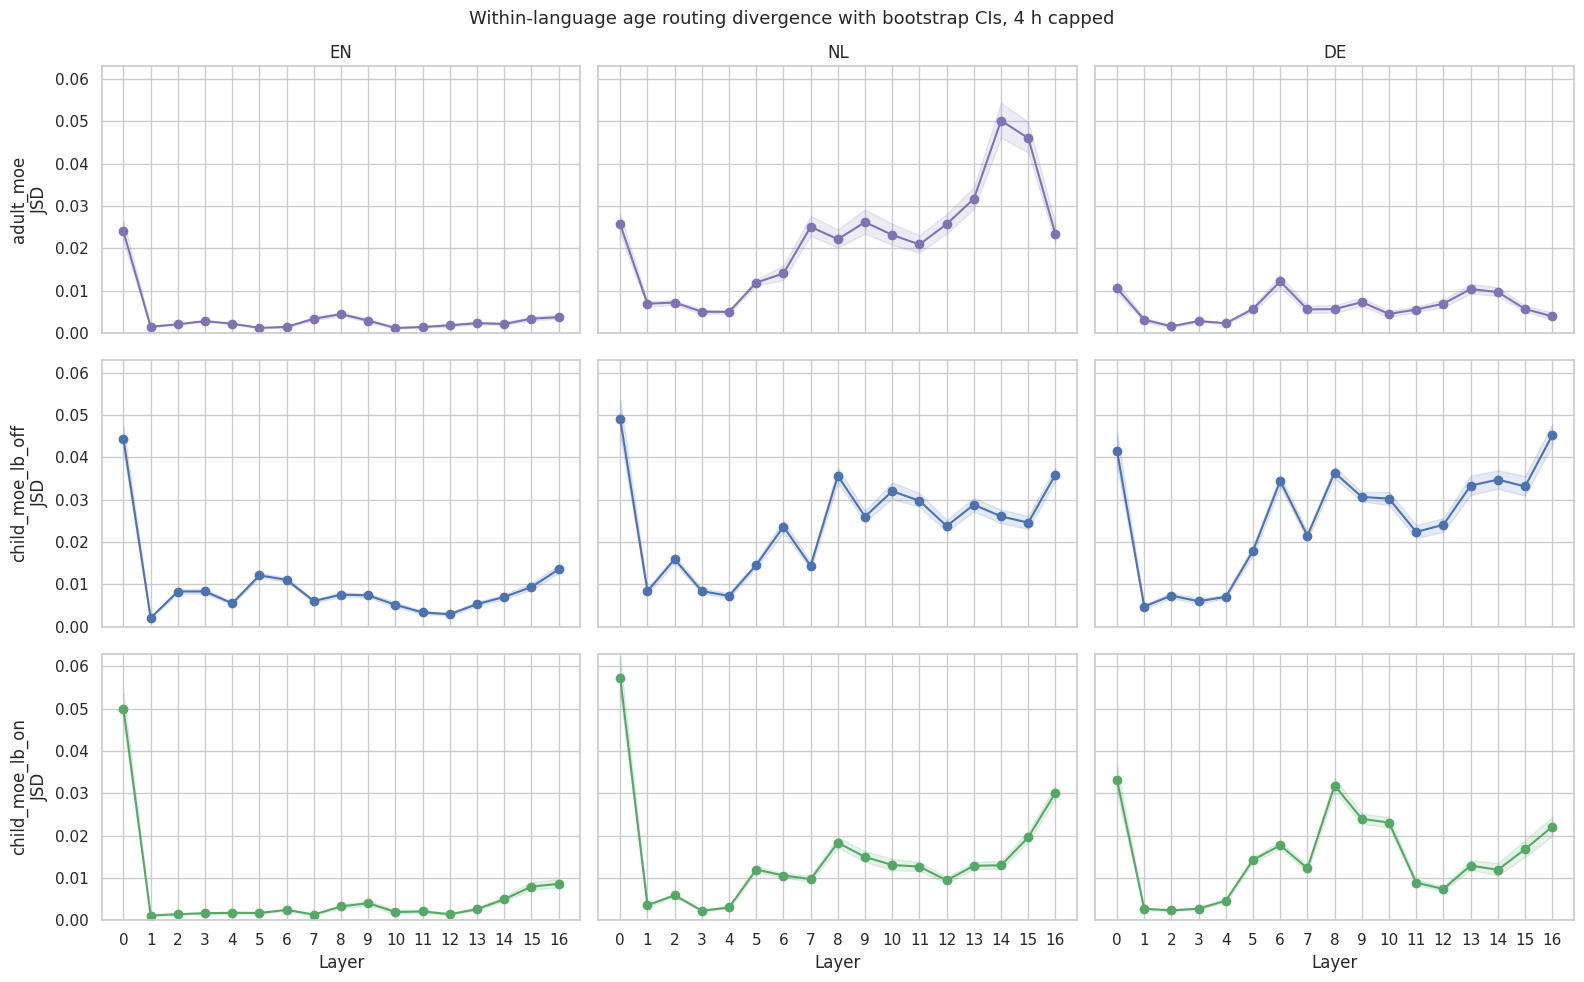

In [9]:
fig, axes = plt.subplots(len(MODEL_NAMES), len(AGE_LANGUAGES), figsize=(16, 10), sharex=True, sharey=True)
if len(MODEL_NAMES)   == 1: axes = np.array([axes])
if len(AGE_LANGUAGES) == 1: axes = axes[:, None]

for r, model_name in enumerate(MODEL_NAMES):
    for c, lang in enumerate(AGE_LANGUAGES):
        ax    = axes[r, c]
        vals  = age_jsd_observed[(model_name, lang)]
        ci    = age_jsd_ci.get((model_name, lang))
        color = MODEL_COLORS[model_name]

        ax.plot(range(NUM_LAYERS), vals, marker="o", color=color)
        if ci is not None:
            ax.fill_between(ci["layer"], ci["ci_low"], ci["ci_high"], alpha=0.15, color=color)

        ax.set_ylim(0, age_ymax)
        ax.set_xticks(range(NUM_LAYERS))
        if r == 0:                    ax.set_title(lang.upper())
        if c == 0:                    ax.set_ylabel(f"{model_name}\nJSD")
        if r == len(MODEL_NAMES) - 1: ax.set_xlabel("Layer")

plt.suptitle("Within-language age routing divergence with bootstrap CIs, 4 h capped", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_jsd_grid_models_languages_ci_4h.png", dpi=200)
plt.show()

---
## Cell 9 — Age specialisation: expert preference delta heatmaps

JSD tells us *how much* routing differs between adults and children, but not *which experts* are preferred. The **expert preference delta** makes this explicit:

$$\Delta_e = (p^{\text{child}}_e - p^{\text{adult}}_e) \times \text{TOP\_K}$$

- **Red cells** (Δ > 0): expert is relatively over-used for child speech.
- **Blue cells** (Δ < 0): expert is relatively over-used for adult speech.

Two figures are produced:
1. **Full grid** (rows = models, columns = languages) for a complete overview.
2. **Primary model only** (single row, three languages) — the cleaner thesis figure.

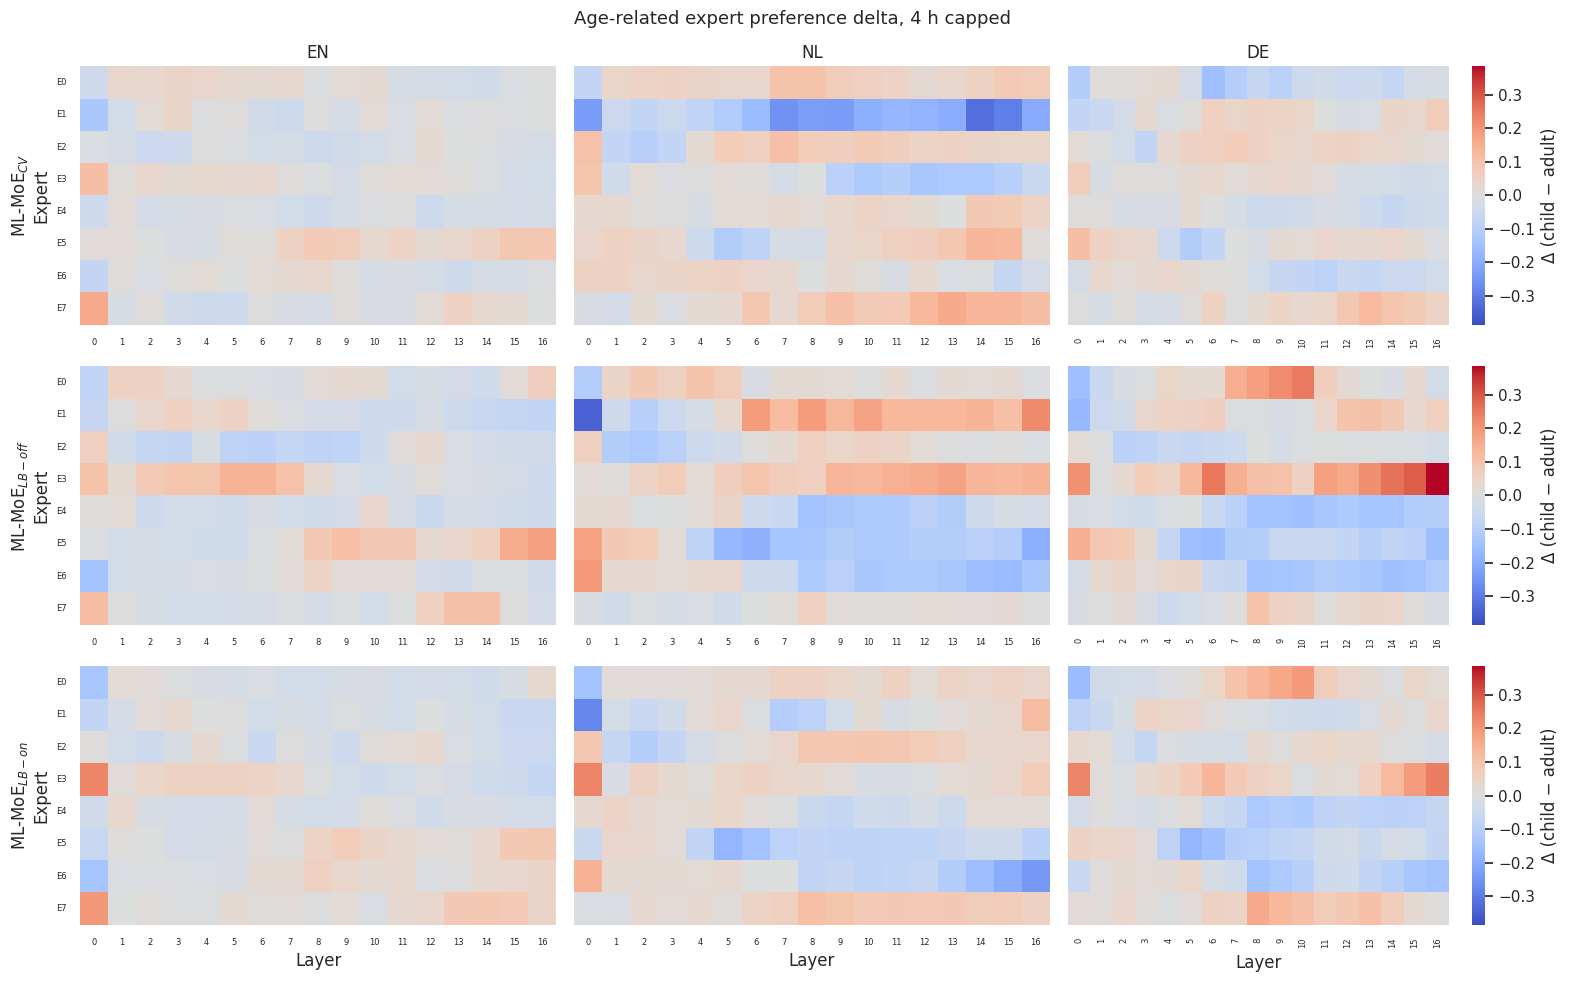

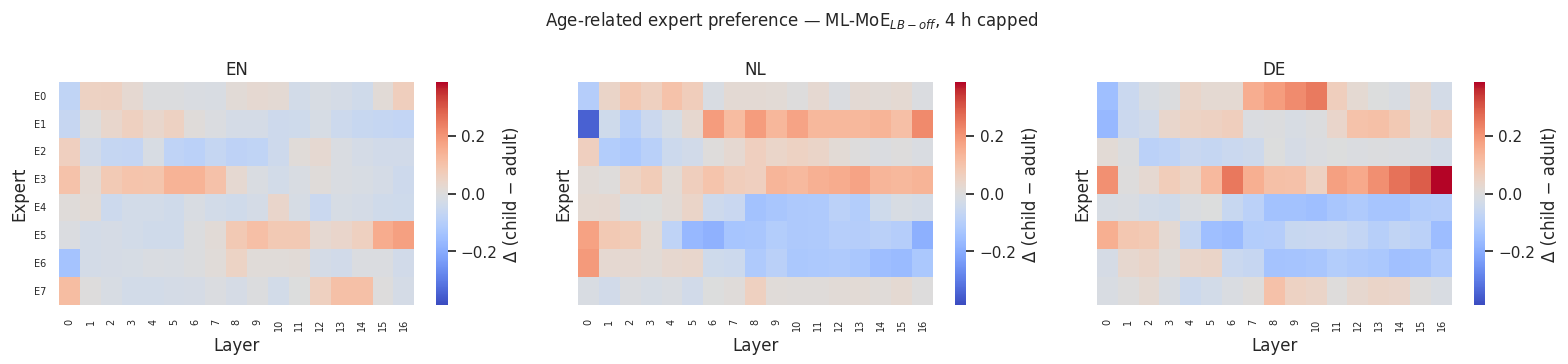

In [10]:
# Compute delta matrices: (NUM_EXPERTS × NUM_LAYERS) per model and language
age_delta = {}
for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})
    for lang in AGE_LANGUAGES:
        mat = np.full((NUM_EXPERTS, NUM_LAYERS), np.nan)
        for layer in range(NUM_LAYERS):
            ld    = md.get(layer, {})
            adult = ld.get((lang, "adult"))
            child = ld.get((lang, "child"))
            if adult is not None and child is not None:
                mat[:, layer] = (child - adult) * TOP_K
        age_delta[(model_name, lang)] = mat

# Shared colour scale across all panels
all_delta_vals = np.concatenate([m.ravel() for m in age_delta.values()])
all_delta_vals = all_delta_vals[~np.isnan(all_delta_vals)]
max_abs = np.max(np.abs(all_delta_vals)) if all_delta_vals.size else 1e-6
if max_abs == 0:
    max_abs = 1e-6


# --- Figure 1: full grid (rows = models, columns = languages) ---
fig, axes = plt.subplots(len(MODEL_NAMES), len(AGE_LANGUAGES), figsize=(16, 10), sharey=True)
if len(MODEL_NAMES)   == 1: axes = np.array([axes])
if len(AGE_LANGUAGES) == 1: axes = axes[:, None]

for r, model_name in enumerate(MODEL_NAMES):
    for c, lang in enumerate(AGE_LANGUAGES):
        ax  = axes[r, c]
        mat = age_delta[(model_name, lang)]
        sns.heatmap(
            mat, cmap="coolwarm", center=0, vmin=-max_abs, vmax=max_abs, ax=ax,
            cbar=(c == len(AGE_LANGUAGES) - 1),
            cbar_kws={"label": "Δ (child − adult)"} if c == len(AGE_LANGUAGES) - 1 else {},
        )
        if r == 0: ax.set_title(lang.upper())
        if c == 0: ax.set_ylabel(f"{model_label(model_name)}\nExpert")
        else:      ax.set_ylabel("")
        ax.set_xlabel("Layer" if r == len(MODEL_NAMES) - 1 else "")
        ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
        ax.set_xticklabels(range(NUM_LAYERS), fontsize=6)
        ax.set_yticks(np.arange(NUM_EXPERTS) + 0.5)
        ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=6)

plt.suptitle("Age-related expert preference delta, 4 h capped", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_delta_grid_models_languages_4h.png", dpi=200)
plt.show()


# --- Figure 2: primary model only (thesis figure) ---
fig, axes = plt.subplots(1, len(AGE_LANGUAGES), figsize=(16, 3.7), sharey=True)
if len(AGE_LANGUAGES) == 1:
    axes = [axes]

for ax, lang in zip(axes, AGE_LANGUAGES):
    mat = age_delta[(PRIMARY_MODEL, lang)]
    sns.heatmap(
        mat, cmap="coolwarm", center=0, vmin=-max_abs, vmax=max_abs, ax=ax,
        cbar_kws={"label": "Δ (child − adult)"},
    )
    ax.set_title(lang.upper())
    ax.set_xlabel("Layer")
    ax.set_ylabel("Expert")
    ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
    ax.set_xticklabels(range(NUM_LAYERS), fontsize=7)
    ax.set_yticks(np.arange(NUM_EXPERTS) + 0.5)
    ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=7)

plt.suptitle(f"Age-related expert preference — {model_label(PRIMARY_MODEL)}, 4 h capped", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_delta_per_language_primary_4h.png", dpi=200)
plt.show()

---
## Cell 10 — Cross-lingual consistency of child-preferred experts

If the same experts are child-preferred across EN, NL, and DE, this suggests that the router has learned features tied to child speech acoustics (e.g., higher F0, formant patterns) rather than language-specific surface characteristics.

Analysis uses the **primary model** (`child_moe_lb_off`) at the **peak age-JSD layers** identified in Cell 6 (one peak per language, supplemented with EN benchmark layers 4/5/13/14 if fewer than four unique peaks are found).

Two complementary figures:
1. **Bar chart** — delta values side-by-side per expert, coloured by language.
2. **Heatmap** — expert × language delta matrix with annotated values for easy reading.

Peak layers per language: {'en': 0, 'nl': 0, 'de': 16}
Key layers: [0, 4, 5, 16]


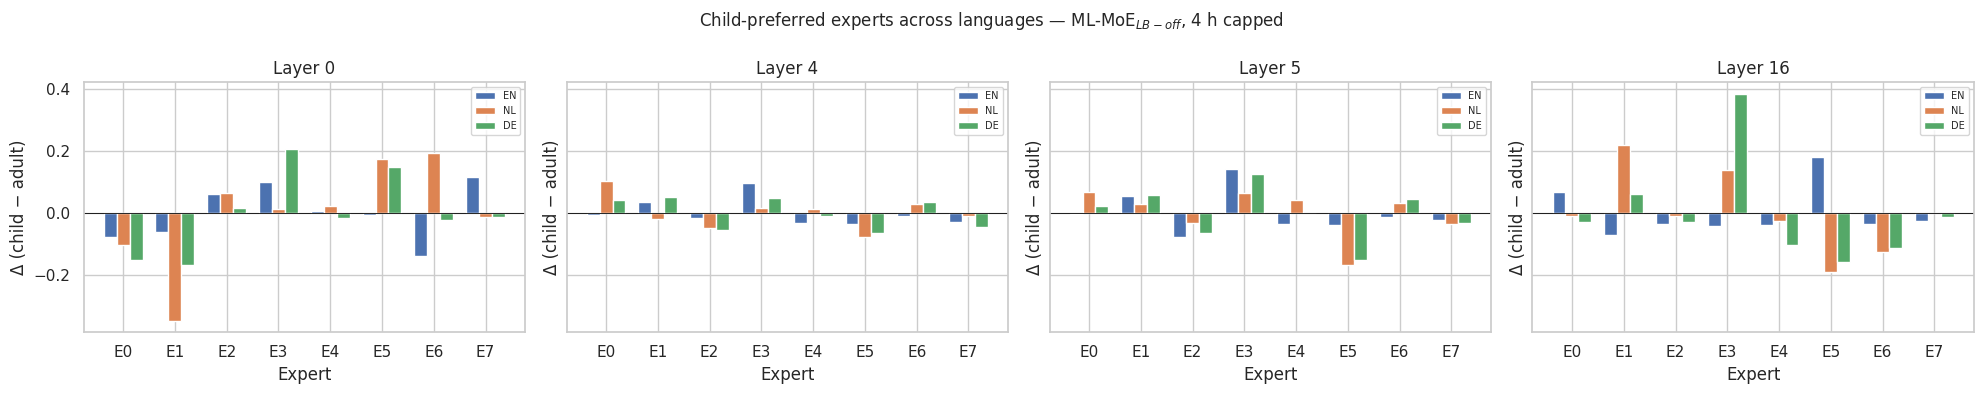

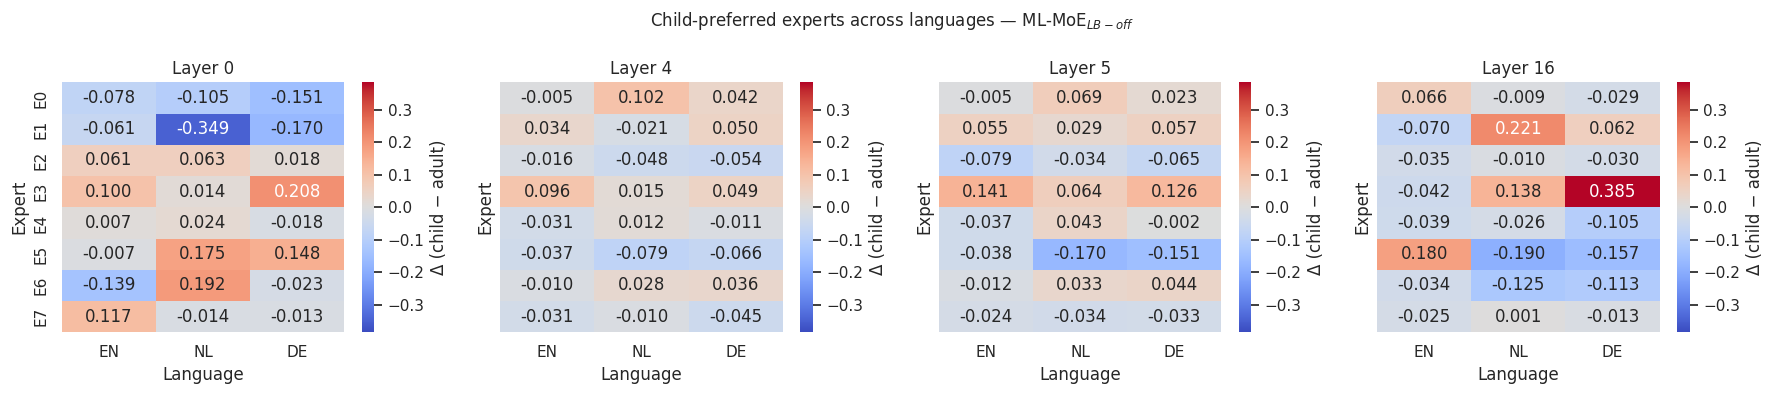


Child-preferred experts (Δ > 0) at key layers for ML-MoE$_{LB-off}$:
  Layer 0:
    EN: E2, E3, E4, E7
    NL: E2, E3, E4, E5, E6
    DE: E2, E3, E5
  Layer 4:
    EN: E1, E3
    NL: E0, E3, E4, E6
    DE: E0, E1, E3, E6
  Layer 5:
    EN: E1, E3
    NL: E0, E1, E3, E4, E6
    DE: E0, E1, E3, E6
  Layer 16:
    EN: E0, E5
    NL: E1, E3, E7
    DE: E1, E3


In [11]:
# Identify peak age-JSD layer per language for the primary model
peak_layers = {}
for lang in AGE_LANGUAGES:
    vals  = age_jsd_observed.get((PRIMARY_MODEL, lang), [])
    valid = [(i, v) for i, v in enumerate(vals) if not np.isnan(v)]
    if valid:
        peak_layers[lang] = max(valid, key=lambda x: x[1])[0]
print("Peak layers per language:", peak_layers)

# Ensure at least 4 key layers (fall back to EN benchmark layers if needed)
key_layers = sorted(set(peak_layers.values()))
for fallback in [4, 5, 13, 14]:
    if len(key_layers) >= 4:
        break
    if fallback not in key_layers:
        key_layers.append(fallback)
key_layers = sorted(key_layers)[:4]
print("Key layers:", key_layers)


# --- Figure 1: bar chart ---
x     = np.arange(NUM_EXPERTS)
width = 0.25

fig, axes = plt.subplots(1, len(key_layers), figsize=(5 * len(key_layers), 4), sharey=True)
if len(key_layers) == 1:
    axes = [axes]

for ax, layer in zip(axes, key_layers):
    for i, lang in enumerate(AGE_LANGUAGES):
        mat    = age_delta[(PRIMARY_MODEL, lang)]
        deltas = mat[:, layer]
        ax.bar(x + i * width, deltas, width, label=lang.upper(), color=LANG_COLORS[lang])
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(f"Layer {layer}")
    ax.set_xlabel("Expert")
    ax.set_ylabel("Δ (child − adult)")
    ax.set_xticks(x + width)
    ax.set_xticklabels([f"E{i}" for i in range(NUM_EXPERTS)])
    ax.legend(fontsize=7)

plt.suptitle(f"Child-preferred experts across languages — {model_label(PRIMARY_MODEL)}, 4 h capped", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_tabulation_delta_4h.png", dpi=200)
plt.show()


# --- Figure 2: heatmaps (expert × language per key layer) ---
crosstab_mats = {}
for layer in key_layers:
    mat = np.full((NUM_EXPERTS, len(AGE_LANGUAGES)), np.nan)
    for c, lang in enumerate(AGE_LANGUAGES):
        delta_mat = age_delta.get((PRIMARY_MODEL, lang))
        if delta_mat is not None:
            mat[:, c] = delta_mat[:, layer]
    crosstab_mats[layer] = mat

all_ct = np.concatenate([m.ravel() for m in crosstab_mats.values()])
all_ct = all_ct[~np.isnan(all_ct)]
ct_max = np.nanmax(np.abs(all_ct)) if all_ct.size else 1e-6
if ct_max == 0:
    ct_max = 1e-6

fig, axes = plt.subplots(1, len(key_layers), figsize=(4.5 * len(key_layers), 4), sharey=True)
if len(key_layers) == 1:
    axes = [axes]

for ax, layer in zip(axes, key_layers):
    sns.heatmap(
        crosstab_mats[layer], cmap="coolwarm", center=0, vmin=-ct_max, vmax=ct_max,
        annot=True, fmt=".3f", ax=ax,
        xticklabels=[l.upper() for l in AGE_LANGUAGES],
        yticklabels=[f"E{i}" for i in range(NUM_EXPERTS)],
        cbar_kws={"label": "Δ (child − adult)"},
    )
    ax.set_title(f"Layer {layer}")
    ax.set_xlabel("Language")
    ax.set_ylabel("Expert")

plt.suptitle(f"Child-preferred experts across languages — {model_label(PRIMARY_MODEL)}", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_tabulation_heatmap_4h.png", dpi=200)
plt.show()


# Print text summary
print(f"\nChild-preferred experts (Δ > 0) at key layers for {model_label(PRIMARY_MODEL)}:")
for layer in key_layers:
    print(f"  Layer {layer}:")
    for lang in AGE_LANGUAGES:
        mat        = age_delta.get((PRIMARY_MODEL, lang))
        child_pref = [f"E{e}" for e in range(NUM_EXPERTS) if mat is not None and mat[e, layer] > 0]
        print(f"    {lang.upper()}: {', '.join(child_pref) if child_pref else 'none'}")

---
## Cell 11 — PAVSig: Polish age routing analysis

> **Important caveat:** PAVSig is a **clinical** corpus of Polish children with *sigmatism* (a speech sound disorder). Routing patterns observed for Polish child speech cannot be attributed to typical child acoustic characteristics (e.g., higher F0, shorter vocal tract) and must not be compared directly to EN/NL/DE results. Results are included for completeness only.

Three outputs if PAVSig data is present:
1. JSD curves per model — how much routing diverges between adult CV-PL and PAVSig children.
2. Expert preference delta heatmaps per model.
3. Summary CSV saved to `OUTPUT_DIR/pavsig_polish_summary_all_models.csv`.

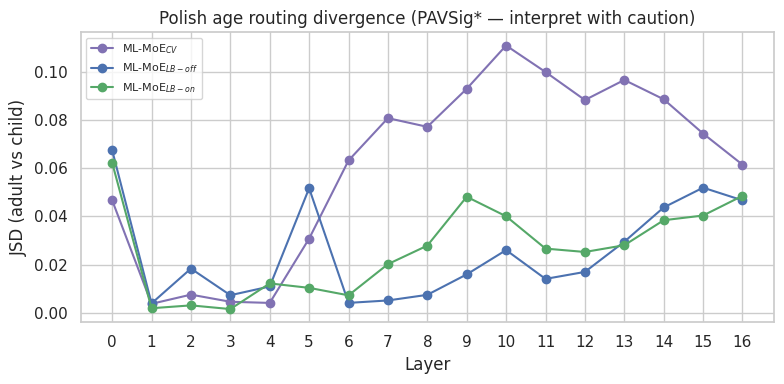

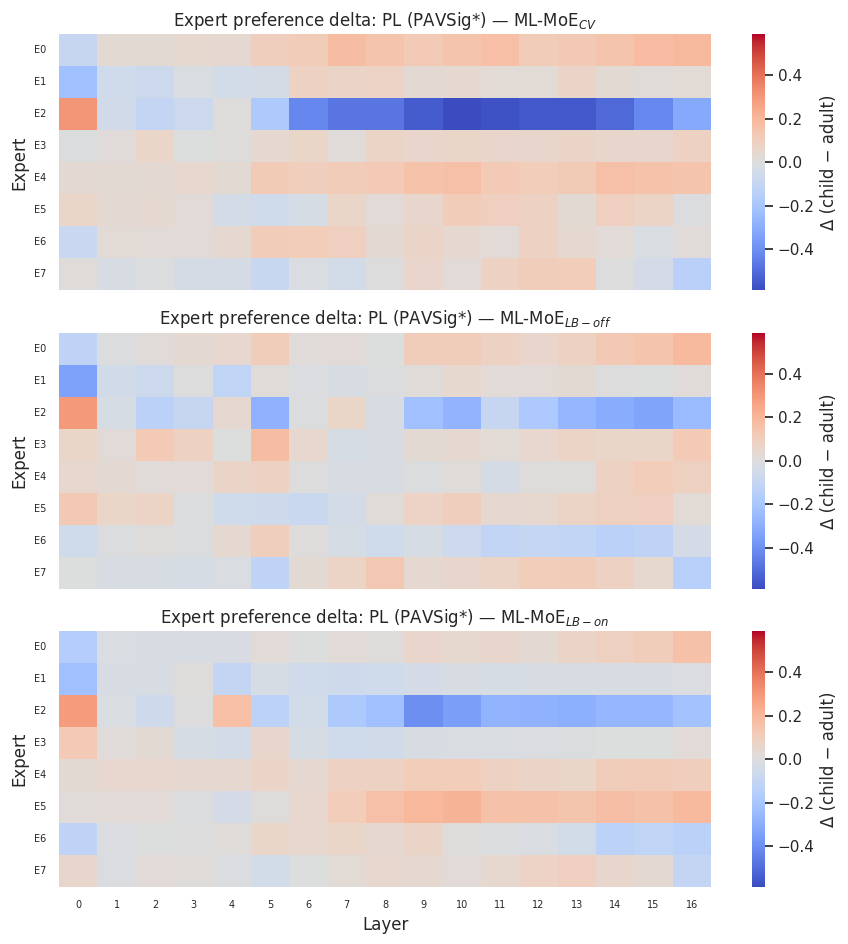


PAVSig Polish summary:
            model        model_key  peak_jsd_layer  peak_jsd  child_pref_expert_at_peak  adult_pref_expert_at_peak  max_delta_at_peak  min_delta_at_peak
    ML-MoE$_{CV}$        adult_moe              10  0.110952                          4                          2           0.165538          -0.588661
ML-MoE$_{LB-off}$ child_moe_lb_off               0  0.067558                          2                          1           0.293183          -0.343381
 ML-MoE$_{LB-on}$  child_moe_lb_on               0  0.062317                          2                          1           0.288934          -0.228146


In [12]:
has_pl_child = any(
    ("pl", "child") in distributions.get(model_name, {}).get(layer, {})
    for model_name in MODEL_NAMES
    for layer in range(NUM_LAYERS)
)

if not has_pl_child:
    print("No Polish child (PAVSig) data found. Skipping.")
    print("Fix PAVSig manifest path and rerun routing extraction.")

else:
    # -----------------------------------------------------------------------
    # 1. JSD per model
    # -----------------------------------------------------------------------
    pl_jsd_by_model = {}
    for model_name in MODEL_NAMES:
        md   = distributions.get(model_name, {})
        vals = []
        for layer in range(NUM_LAYERS):
            ld    = md.get(layer, {})
            adult = ld.get(("pl", "adult"))
            child = ld.get(("pl", "child"))
            vals.append(jsd(adult, child) if adult is not None and child is not None else np.nan)
        pl_jsd_by_model[model_name] = vals

    # -----------------------------------------------------------------------
    # 2. JSD plot — all models
    # -----------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 4))
    for model_name in MODEL_NAMES:
        ax.plot(
            range(NUM_LAYERS), pl_jsd_by_model[model_name],
            marker="o", label=model_label(model_name), color=MODEL_COLORS[model_name],
        )
    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD (adult vs child)")
    ax.set_title("Polish age routing divergence (PAVSig* — interpret with caution)")
    ax.set_xticks(range(NUM_LAYERS))
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "pavsig_polish_jsd_all_models.png", dpi=300, bbox_inches="tight")
    plt.show()

    # -----------------------------------------------------------------------
    # 3. Expert preference delta per model
    # -----------------------------------------------------------------------
    pl_delta_by_model = {}
    for model_name in MODEL_NAMES:
        md  = distributions.get(model_name, {})
        mat = np.full((NUM_EXPERTS, NUM_LAYERS), np.nan)
        for layer in range(NUM_LAYERS):
            ld    = md.get(layer, {})
            adult = ld.get(("pl", "adult"))
            child = ld.get(("pl", "child"))
            if adult is not None and child is not None:
                mat[:, layer] = (child - adult) * TOP_K
        pl_delta_by_model[model_name] = mat

    # Shared colour scale
    all_pl = np.concatenate([m.ravel() for m in pl_delta_by_model.values()])
    all_pl = all_pl[~np.isnan(all_pl)]
    pmax   = np.nanmax(np.abs(all_pl)) if all_pl.size else 1e-6
    if pmax == 0:
        pmax = 1e-6

    fig, axes = plt.subplots(
        nrows=len(MODEL_NAMES), ncols=1,
        figsize=(9, 3.2 * len(MODEL_NAMES)),
        sharex=True, sharey=True,
    )
    if len(MODEL_NAMES) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, MODEL_NAMES):
        sns.heatmap(
            pl_delta_by_model[model_name], cmap="coolwarm", center=0,
            vmin=-pmax, vmax=pmax, ax=ax, cbar_kws={"label": "Δ (child − adult)"},
        )
        ax.set_title(f"Expert preference delta: PL (PAVSig*) — {model_label(model_name)}")
        ax.set_ylabel("Expert")
        ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
        ax.set_xticklabels(range(NUM_LAYERS), fontsize=7)
        ax.set_yticks(np.arange(NUM_EXPERTS) + 0.5)
        ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=7)
    axes[-1].set_xlabel("Layer")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "pavsig_polish_delta_all_models.png", dpi=300, bbox_inches="tight")
    plt.show()

    # -----------------------------------------------------------------------
    # 4. Summary CSV
    # -----------------------------------------------------------------------
    summary_rows = []
    for model_name in MODEL_NAMES:
        vals = np.array(pl_jsd_by_model[model_name], dtype=float)
        if np.all(np.isnan(vals)):
            peak_layer = peak_jsd = np.nan
        else:
            peak_layer = int(np.nanargmax(vals))
            peak_jsd   = float(np.nanmax(vals))

        mat = pl_delta_by_model[model_name]
        if np.all(np.isnan(mat)) or np.isnan(peak_layer):
            child_pref_expert = adult_pref_expert = max_delta = min_delta = np.nan
        else:
            peak_mat          = mat[:, int(peak_layer)]
            child_pref_expert = int(np.nanargmax(peak_mat))
            adult_pref_expert = int(np.nanargmin(peak_mat))
            max_delta         = float(np.nanmax(peak_mat))
            min_delta         = float(np.nanmin(peak_mat))

        summary_rows.append({
            "model":                     model_label(model_name),
            "model_key":                 model_name,
            "peak_jsd_layer":            peak_layer,
            "peak_jsd":                  peak_jsd,
            "child_pref_expert_at_peak": child_pref_expert,
            "adult_pref_expert_at_peak": adult_pref_expert,
            "max_delta_at_peak":         max_delta,
            "min_delta_at_peak":         min_delta,
        })

    pl_summary = pd.DataFrame(summary_rows)
    pl_summary.to_csv(OUTPUT_DIR / "pavsig_polish_summary_all_models.csv", index=False)
    print("\nPAVSig Polish summary:")
    print(pl_summary.to_string(index=False))